# 📊 Trafik İşareti Veri Seti Analizi

Bu notebook, trafik işareti tanıma projesi için kullanılan veri setinin detaylı analizini içerir.

## Analiz Adımları:
1. **Veri Seti Genel Bilgileri**
2. **Sınıf Dağılımı Analizi**
3. **Görsel Boyut ve Kalite Analizi**
4. **Etiket Analizi**
5. **Veri Dengesizliği Kontrolü**
6. **Örnek Görsel Görselleştirmeleri**

## 1. Kütüphaneleri Yükle

In [1]:
import os
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Matplotlib Türkçe karakter desteği
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# Görsel ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

print("✅ Kütüphaneler yüklendi!")

✅ Kütüphaneler yüklendi!


## 2. Veri Seti Yollarını Tanımla

In [2]:
# Proje ana klasörü
PROJECT_ROOT = Path(r"c:\Users\Baver Koca\Desktop\Hatice\modelegtm")

# Dataset klasörleri
DATASET_ORIGINAL = PROJECT_ROOT / "dataset"
DATASET_CLEANED = PROJECT_ROOT / "dataset_cleaned"

# Hangi dataseti analiz edeceğiz?
DATASET_PATH = DATASET_CLEANED  # Temizlenmiş veriyi kullan

print(f"📁 Proje Klasörü: {PROJECT_ROOT}")
print(f"📂 Analiz Edilecek Dataset: {DATASET_PATH}")
print(f"✅ Dataset var mı: {DATASET_PATH.exists()}")

# data.yaml dosyasını oku
data_yaml_path = DATASET_PATH / "data.yaml"
if data_yaml_path.exists():
    with open(data_yaml_path, 'r', encoding='utf-8') as f:
        data_config = yaml.safe_load(f)
    print(f"\n📋 Veri Seti Konfigürasyonu:")
    print(f"   • Sınıf Sayısı: {data_config['nc']}")
    print(f"   • Train Path: {data_config['train']}")
    print(f"   • Valid Path: {data_config['val']}")
    print(f"   • Test Path: {data_config['test']}")
else:
    print("⚠️ data.yaml dosyası bulunamadı!")

📁 Proje Klasörü: c:\Users\Baver Koca\Desktop\Hatice\modelegtm
📂 Analiz Edilecek Dataset: c:\Users\Baver Koca\Desktop\Hatice\modelegtm\dataset_cleaned
✅ Dataset var mı: True

📋 Veri Seti Konfigürasyonu:
   • Sınıf Sayısı: 264
   • Train Path: train/images
   • Valid Path: valid/images
   • Test Path: test/images


## 3. Veri Seti İstatistiklerini Topla

In [3]:
def count_files(directory, extension='.jpg'):
    """Belirtilen uzantıdaki dosyaları say"""
    if not directory.exists():
        return 0
    return len(list(directory.glob(f'*{extension}')))

# Her split için istatistikleri topla
splits = ['train', 'valid', 'test']
stats = {}

for split in splits:
    images_dir = DATASET_PATH / split / 'images'
    labels_dir = DATASET_PATH / split / 'labels'
    
    num_images = count_files(images_dir, '.jpg') + count_files(images_dir, '.png')
    num_labels = count_files(labels_dir, '.txt')
    
    stats[split] = {
        'images': num_images,
        'labels': num_labels,
        'images_dir': images_dir,
        'labels_dir': labels_dir
    }

# İstatistikleri göster
print("=" * 70)
print("📊 VERI SETİ GENEL İSTATİSTİKLER")
print("=" * 70)

df_stats = pd.DataFrame({
    'Split': splits,
    'Görsel Sayısı': [stats[s]['images'] for s in splits],
    'Etiket Sayısı': [stats[s]['labels'] for s in splits],
    'Eşleşme': ['✅' if stats[s]['images'] == stats[s]['labels'] else '❌' for s in splits]
})

print(df_stats.to_string(index=False))
print("=" * 70)

total_images = sum(stats[s]['images'] for s in splits)
print(f"\n🖼️  Toplam Görsel: {total_images}")
print(f"📊 Train Oranı: %{(stats['train']['images']/total_images*100):.1f}")
print(f"📊 Valid Oranı: %{(stats['valid']['images']/total_images*100):.1f}")
print(f"📊 Test Oranı: %{(stats['test']['images']/total_images*100):.1f}")

# Test seti uyarısı
if stats['test']['images'] < 50:
    print(f"\n⚠️  UYARI: Test seti çok küçük ({stats['test']['images']} görsel)!")
    print("   Öneri: En az 50-100 görsel olmalı.")

📊 VERI SETİ GENEL İSTATİSTİKLER
Split  Görsel Sayısı  Etiket Sayısı Eşleşme
train            818            818       ✅
valid            185            185       ✅
 test            355            355       ✅

🖼️  Toplam Görsel: 1358
📊 Train Oranı: %60.2
📊 Valid Oranı: %13.6
📊 Test Oranı: %26.1


## 4. Sınıf Dağılımı Analizi

In [4]:
def parse_yolo_labels(label_file):
    """YOLO format etiket dosyasını parse et"""
    classes = []
    if not label_file.exists():
        return classes
    
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:  # class_id x_center y_center width height
                class_id = int(parts[0])
                classes.append(class_id)
    return classes

# Her split için sınıf dağılımını topla
class_distribution = defaultdict(lambda: Counter())

print("🔍 Etiket dosyaları analiz ediliyor...")
for split in splits:
    labels_dir = stats[split]['labels_dir']
    if labels_dir.exists():
        label_files = list(labels_dir.glob('*.txt'))
        for label_file in label_files:
            classes = parse_yolo_labels(label_file)
            for cls in classes:
                class_distribution[split][cls] += 1
    print(f"   ✅ {split}: {len(label_files)} etiket dosyası işlendi")

print("\n📊 Sınıf Dağılımı Özeti:")
print("=" * 70)
for split in splits:
    total_annotations = sum(class_distribution[split].values())
    unique_classes = len(class_distribution[split])
    print(f"{split.upper():6s}: {total_annotations:5d} annotation, {unique_classes:3d} benzersiz sınıf")
print("=" * 70)

🔍 Etiket dosyaları analiz ediliyor...
   ✅ train: 818 etiket dosyası işlendi
   ✅ valid: 185 etiket dosyası işlendi
   ✅ test: 355 etiket dosyası işlendi

📊 Sınıf Dağılımı Özeti:
TRAIN :  2642 annotation, 262 benzersiz sınıf
VALID :   641 annotation, 209 benzersiz sınıf
TEST  :   848 annotation, 260 benzersiz sınıf


In [5]:
# Sınıf isimlerini yükle
class_names = data_config.get('names', [])
print(f"\n📋 Toplam Sınıf Sayısı (data.yaml): {len(class_names)}")

# Train setindeki en yaygın ve en nadir sınıfları bul
train_dist = class_distribution['train']
if train_dist:
    most_common = train_dist.most_common(10)
    least_common = sorted(train_dist.items(), key=lambda x: x[1])[:10]
    
    print("\n🔝 EN YAYGIN 10 SINIF (Train):")
    print("-" * 70)
    for i, (cls_id, count) in enumerate(most_common, 1):
        cls_name = class_names[cls_id] if cls_id < len(class_names) else f"Class_{cls_id}"
        print(f"{i:2d}. [{cls_id:3d}] {cls_name:40s}: {count:4d} örnek")
    
    print("\n🔻 EN NADİR 10 SINIF (Train):")
    print("-" * 70)
    for i, (cls_id, count) in enumerate(least_common, 1):
        cls_name = class_names[cls_id] if cls_id < len(class_names) else f"Class_{cls_id}"
        print(f"{i:2d}. [{cls_id:3d}] {cls_name:40s}: {count:4d} örnek")
    
    # İmbalanced sınıfları tespit et
    max_count = most_common[0][1]
    min_count = least_common[0][1]
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\n⚖️  Veri Dengesizliği:")
    print(f"   • En fazla örnek: {max_count}")
    print(f"   • En az örnek: {min_count}")
    print(f"   • Dengesizlik oranı: {imbalance_ratio:.1f}x")
    
    if imbalance_ratio > 50:
        print(f"   ⚠️  UYARI: Yüksek veri dengesizliği! Bazı sınıflar yetersiz.")


📋 Toplam Sınıf Sayısı (data.yaml): 264

🔝 EN YAYGIN 10 SINIF (Train):
----------------------------------------------------------------------
 1. [ 57] 166                                     :  147 örnek
 2. [ 12] 111                                     :   87 örnek
 3. [109] 55                                      :   85 örnek
 4. [ 73] 181                                     :   62 örnek
 5. [131] 82                                      :   61 örnek
 6. [  2] 100                                     :   44 örnek
 7. [  5] 103                                     :   41 örnek
 8. [ 13] 112                                     :   39 örnek
 9. [111] 57                                      :   39 örnek
10. [121] 69                                      :   34 örnek

🔻 EN NADİR 10 SINIF (Train):
----------------------------------------------------------------------
 1. [169] Horn prohibited                         :    1 örnek
 2. [243] falling rocks (from) left               :    1 örnek
 

## 5. Sınıf Dağılımı Görselleştirme

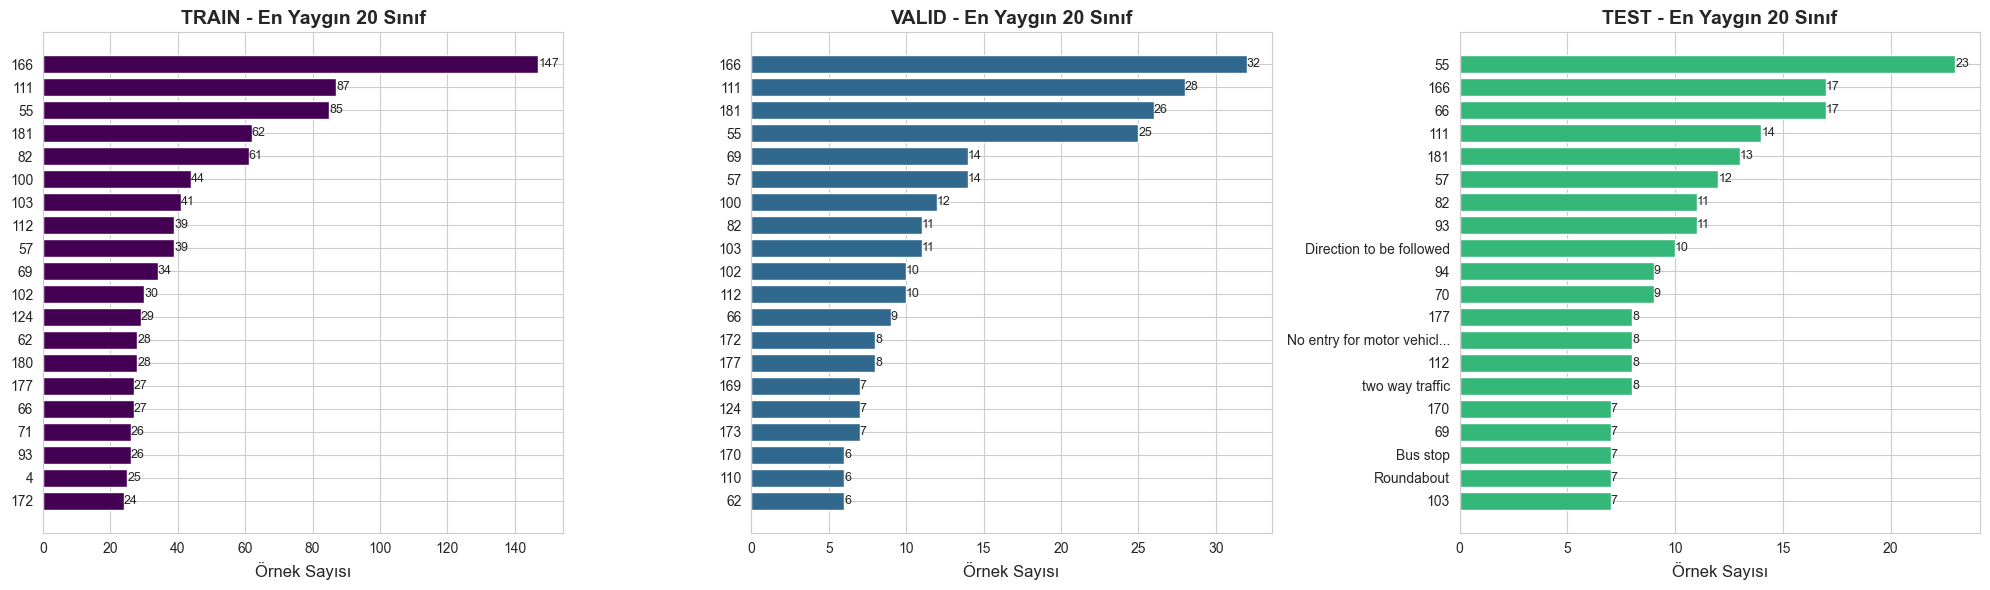

✅ Grafik kaydedildi: class_distribution_top20.png


In [6]:
# En yaygın 20 sınıfın dağılımını görselleştir
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, split in enumerate(splits):
    dist = class_distribution[split]
    if dist:
        # En yaygın 20 sınıf
        top_20 = dict(dist.most_common(20))
        classes = [class_names[cls] if cls < len(class_names) else f"C{cls}" 
                   for cls in top_20.keys()]
        counts = list(top_20.values())
        
        # Kısa etiketler için isimleri kısalt
        classes = [c[:25] + '...' if len(c) > 25 else c for c in classes]
        
        ax = axes[idx]
        bars = ax.barh(classes, counts, color=plt.cm.viridis(idx/3))
        ax.set_xlabel('Örnek Sayısı', fontsize=12)
        ax.set_title(f'{split.upper()} - En Yaygın 20 Sınıf', fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        
        # Değerleri barların üzerine yaz
        for bar in bars:
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2, 
                   f'{int(width)}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik kaydedildi: class_distribution_top20.png")

## 6. Görsel Boyut Analizi

In [7]:
def analyze_image_sizes(images_dir, max_samples=200):
    """Görsellerin boyutlarını analiz et"""
    sizes = []
    aspect_ratios = []
    
    image_files = list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png'))
    # Çok fazla görsel varsa örnekle
    if len(image_files) > max_samples:
        import random
        image_files = random.sample(image_files, max_samples)
    
    for img_file in image_files:
        img = cv2.imread(str(img_file))
        if img is not None:
            h, w = img.shape[:2]
            sizes.append((w, h))
            aspect_ratios.append(w / h)
    
    return sizes, aspect_ratios

print("📏 Görsel boyutları analiz ediliyor...")
image_sizes = {}
aspect_ratios = {}

for split in splits:
    images_dir = stats[split]['images_dir']
    if images_dir.exists():
        sizes, ratios = analyze_image_sizes(images_dir)
        image_sizes[split] = sizes
        aspect_ratios[split] = ratios
        print(f"   ✅ {split}: {len(sizes)} görsel analiz edildi")

# İstatistikleri hesapla ve göster
print("\n" + "=" * 70)
print("📐 GÖRSEL BOYUT İSTATİSTİKLERİ")
print("=" * 70)

for split in splits:
    if split in image_sizes and image_sizes[split]:
        sizes = image_sizes[split]
        widths = [s[0] for s in sizes]
        heights = [s[1] for s in sizes]
        ratios = aspect_ratios[split]
        
        print(f"\n{split.upper()}:")
        print(f"  Genişlik  → Min: {min(widths):4d}, Max: {max(widths):4d}, Ort: {np.mean(widths):.1f}")
        print(f"  Yükseklik → Min: {min(heights):4d}, Max: {max(heights):4d}, Ort: {np.mean(heights):.1f}")
        print(f"  En-Boy    → Min: {min(ratios):.2f}, Max: {max(ratios):.2f}, Ort: {np.mean(ratios):.2f}")

print("=" * 70)

📏 Görsel boyutları analiz ediliyor...
   ✅ train: 200 görsel analiz edildi
   ✅ valid: 185 görsel analiz edildi
   ✅ test: 200 görsel analiz edildi

📐 GÖRSEL BOYUT İSTATİSTİKLERİ

TRAIN:
  Genişlik  → Min:  640, Max:  640, Ort: 640.0
  Yükseklik → Min:  640, Max:  640, Ort: 640.0
  En-Boy    → Min: 1.00, Max: 1.00, Ort: 1.00

VALID:
  Genişlik  → Min:  640, Max:  640, Ort: 640.0
  Yükseklik → Min:  640, Max:  640, Ort: 640.0
  En-Boy    → Min: 1.00, Max: 1.00, Ort: 1.00

TEST:
  Genişlik  → Min:  640, Max:  640, Ort: 640.0
  Yükseklik → Min:  640, Max:  640, Ort: 640.0
  En-Boy    → Min: 1.00, Max: 1.00, Ort: 1.00


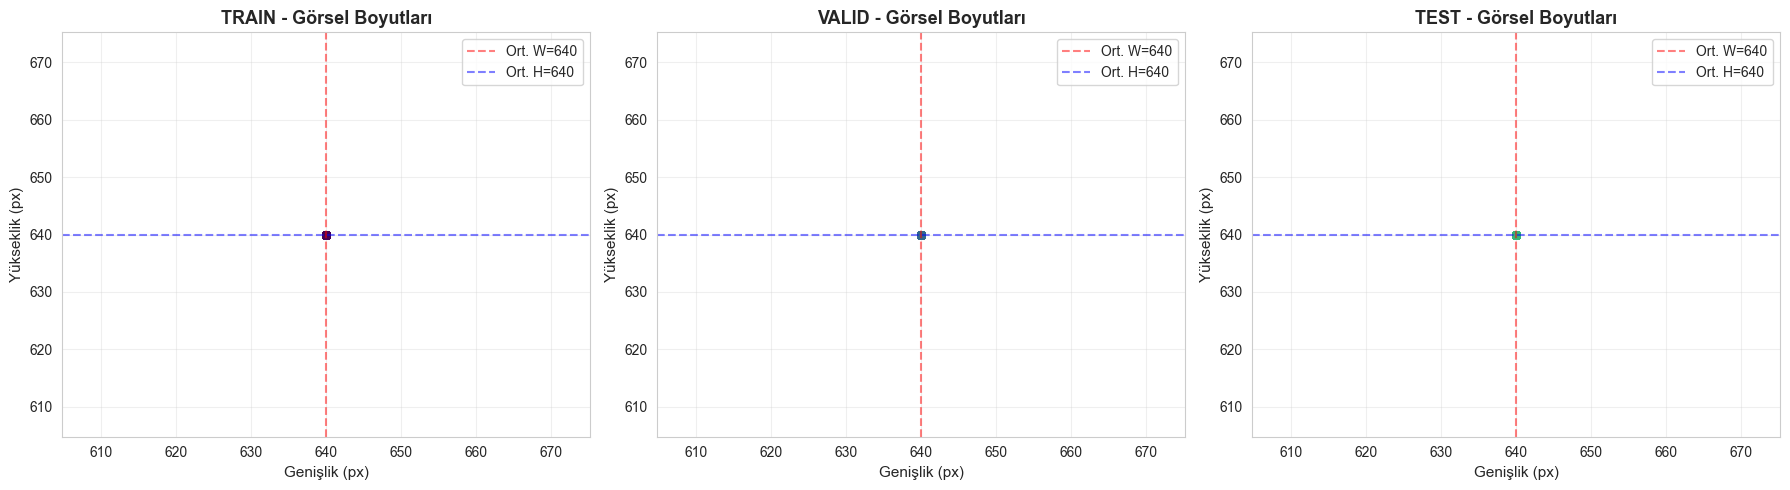

✅ Grafik kaydedildi: image_size_distribution.png


In [8]:
# Boyut dağılımını görselleştir
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, split in enumerate(splits):
    if split in image_sizes and image_sizes[split]:
        sizes = image_sizes[split]
        widths = [s[0] for s in sizes]
        heights = [s[1] for s in sizes]
        
        ax = axes[idx]
        ax.scatter(widths, heights, alpha=0.6, s=30, c=plt.cm.viridis(idx/3))
        ax.set_xlabel('Genişlik (px)', fontsize=11)
        ax.set_ylabel('Yükseklik (px)', fontsize=11)
        ax.set_title(f'{split.upper()} - Görsel Boyutları', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Ortalama çizgi ekle
        mean_w, mean_h = np.mean(widths), np.mean(heights)
        ax.axvline(mean_w, color='red', linestyle='--', alpha=0.5, label=f'Ort. W={mean_w:.0f}')
        ax.axhline(mean_h, color='blue', linestyle='--', alpha=0.5, label=f'Ort. H={mean_h:.0f}')
        ax.legend()

plt.tight_layout()
plt.savefig('image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik kaydedildi: image_size_distribution.png")

## 7. Örnek Görselleri Görselleştir

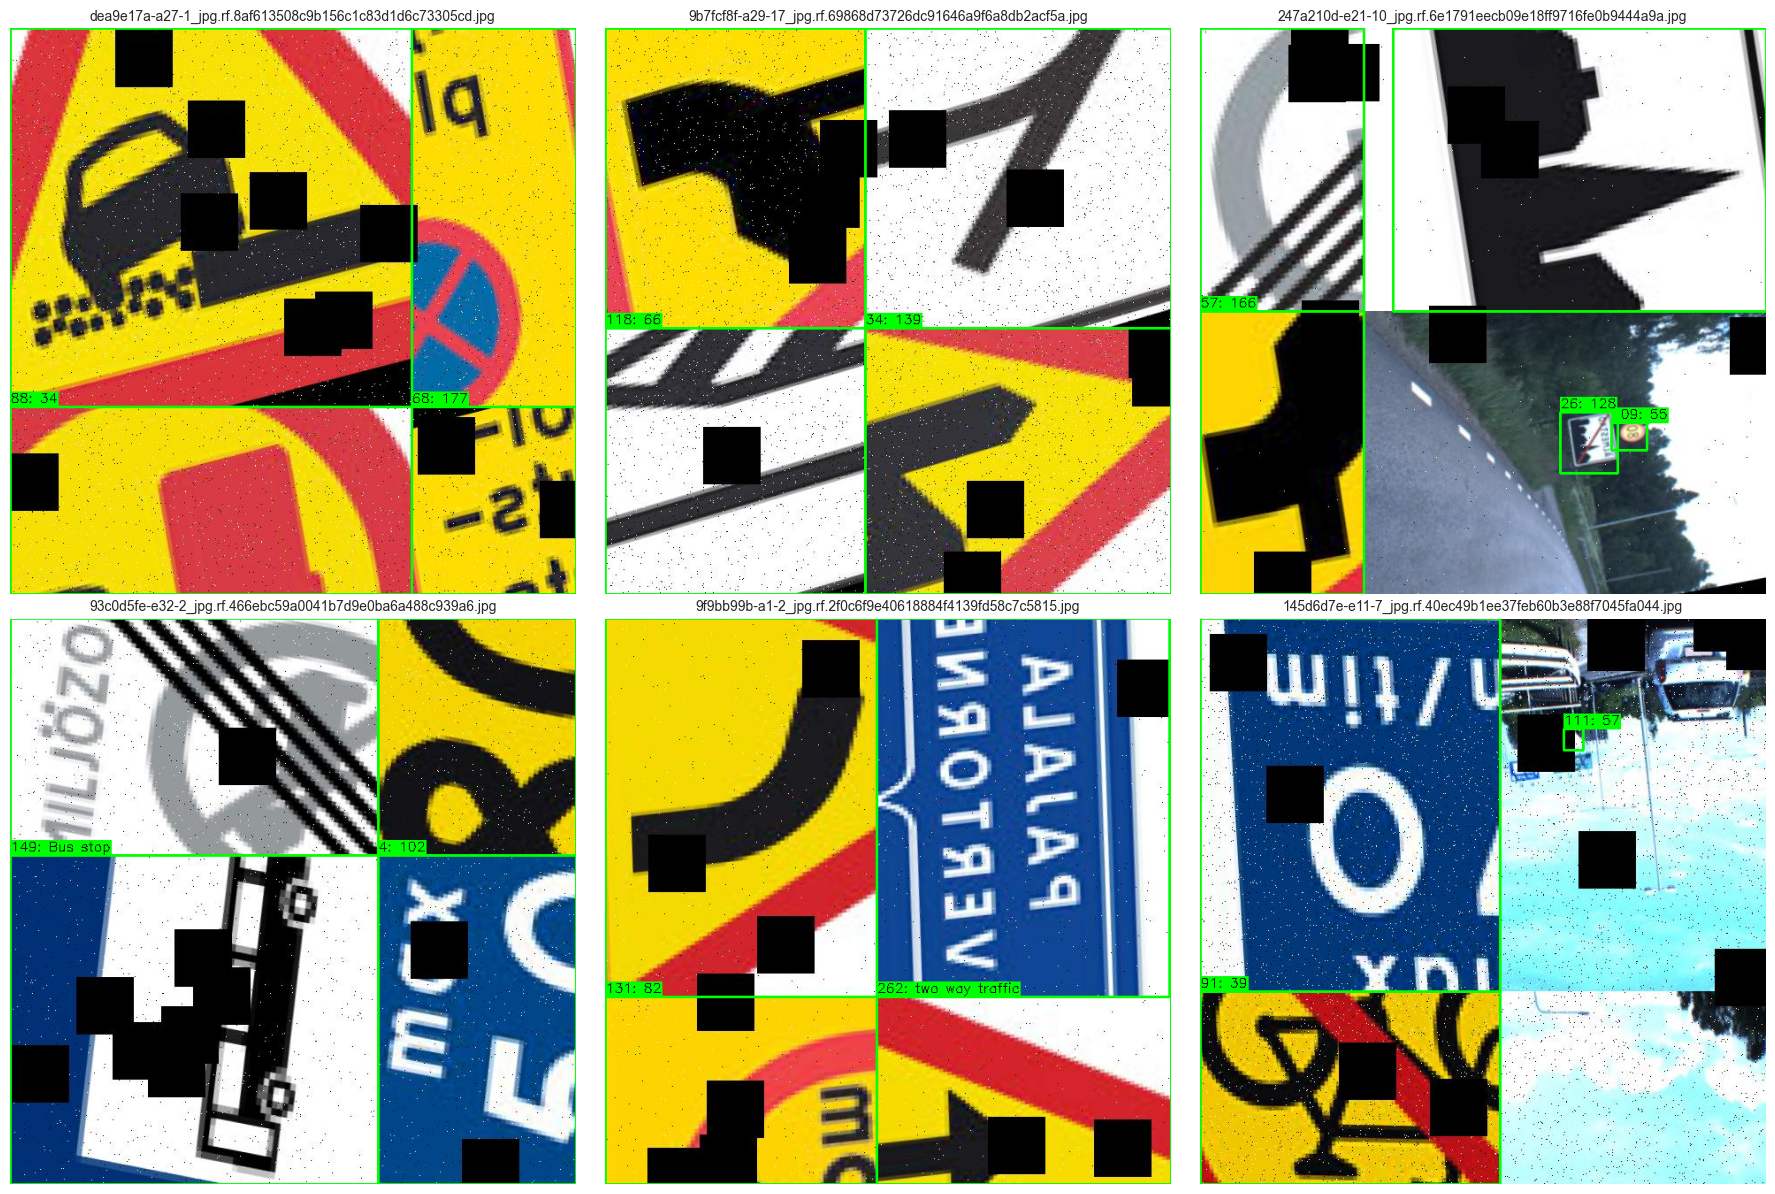

✅ Örnek görseller görselleştirildi ve kaydedildi: sample_images_with_boxes.png


In [9]:
def draw_yolo_boxes(image, label_file, class_names):
    """YOLO formatındaki etiketleri görsel üzerine çiz"""
    img = image.copy()
    h, w = img.shape[:2]
    
    if not label_file.exists():
        return img
    
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:5])
                
                # Normalize koordinatları piksel koordinatlarına çevir
                x_center *= w
                y_center *= h
                width *= w
                height *= h
                
                # Köşe koordinatları
                x1 = int(x_center - width/2)
                y1 = int(y_center - height/2)
                x2 = int(x_center + width/2)
                y2 = int(y_center + height/2)
                
                # Kutu ve etiket çiz
                color = (0, 255, 0)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                
                # Sınıf ismi
                class_name = class_names[class_id] if class_id < len(class_names) else f"Class_{class_id}"
                label = f"{class_id}: {class_name[:20]}"
                
                # Etiket arka planı
                (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(img, (x1, y1 - text_h - 5), (x1 + text_w, y1), color, -1)
                cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    return img

# Train setinden rastgele 6 görsel seç ve görselleştir
import random

train_images_dir = stats['train']['images_dir']
train_labels_dir = stats['train']['labels_dir']

if train_images_dir.exists():
    image_files = list(train_images_dir.glob('*.jpg')) + list(train_images_dir.glob('*.png'))
    if len(image_files) > 0:
        sample_images = random.sample(image_files, min(6, len(image_files)))
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for idx, img_file in enumerate(sample_images):
            # Görseli oku
            img = cv2.imread(str(img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Etiket dosyasını bul
            label_file = train_labels_dir / (img_file.stem + '.txt')
            
            # Kutularla görselleştir
            img_with_boxes = draw_yolo_boxes(img, label_file, class_names)
            
            # Göster
            axes[idx].imshow(img_with_boxes)
            axes[idx].set_title(img_file.name, fontsize=10)
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig('sample_images_with_boxes.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("✅ Örnek görseller görselleştirildi ve kaydedildi: sample_images_with_boxes.png")
    else:
        print("⚠️  Train klasöründe görsel bulunamadı!")

## 8. Bounding Box Analizi

In [10]:
def analyze_bboxes(labels_dir):
    """Bounding box boyutlarını analiz et"""
    box_widths = []
    box_heights = []
    box_areas = []
    
    if not labels_dir.exists():
        return box_widths, box_heights, box_areas
    
    label_files = list(labels_dir.glob('*.txt'))
    
    for label_file in label_files:
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    width = float(parts[3])  # Normalize edilmiş genişlik
                    height = float(parts[4])  # Normalize edilmiş yükseklik
                    area = width * height
                    
                    box_widths.append(width)
                    box_heights.append(height)
                    box_areas.append(area)
    
    return box_widths, box_heights, box_areas

# Her split için bbox analizi
print("📦 Bounding box analizi yapılıyor...")
bbox_stats = {}

for split in splits:
    labels_dir = stats[split]['labels_dir']
    widths, heights, areas = analyze_bboxes(labels_dir)
    bbox_stats[split] = {
        'widths': widths,
        'heights': heights,
        'areas': areas
    }
    print(f"   ✅ {split}: {len(widths)} bbox analiz edildi")

# İstatistikleri göster
print("\n" + "=" * 70)
print("📦 BOUNDING BOX İSTATİSTİKLERİ (Normalize Değerler)")
print("=" * 70)

for split in splits:
    if bbox_stats[split]['widths']:
        widths = bbox_stats[split]['widths']
        heights = bbox_stats[split]['heights']
        areas = bbox_stats[split]['areas']
        
        print(f"\n{split.upper()}:")
        print(f"  Genişlik → Min: {min(widths):.3f}, Max: {max(widths):.3f}, Ort: {np.mean(widths):.3f}")
        print(f"  Yükseklik → Min: {min(heights):.3f}, Max: {max(heights):.3f}, Ort: {np.mean(heights):.3f}")
        print(f"  Alan     → Min: {min(areas):.4f}, Max: {max(areas):.4f}, Ort: {np.mean(areas):.4f}")
        
        # Çok küçük nesneleri tespit et
        very_small = sum(1 for a in areas if a < 0.01)
        if very_small > 0:
            print(f"  ⚠️  Çok küçük nesneler (alan < 0.01): {very_small} adet")

print("=" * 70)

📦 Bounding box analizi yapılıyor...
   ✅ train: 2642 bbox analiz edildi
   ✅ valid: 641 bbox analiz edildi
   ✅ test: 848 bbox analiz edildi

📦 BOUNDING BOX İSTATİSTİKLERİ (Normalize Değerler)

TRAIN:
  Genişlik → Min: 0.002, Max: 1.000, Ort: 0.479
  Yükseklik → Min: 0.005, Max: 1.000, Ort: 0.479
  Alan     → Min: 0.0000, Max: 1.0000, Ort: 0.2650
  ⚠️  Çok küçük nesneler (alan < 0.01): 232 adet

VALID:
  Genişlik → Min: 0.018, Max: 1.000, Ort: 0.456
  Yükseklik → Min: 0.017, Max: 1.000, Ort: 0.457
  Alan     → Min: 0.0004, Max: 1.0000, Ort: 0.2426
  ⚠️  Çok küçük nesneler (alan < 0.01): 71 adet

TEST:
  Genişlik → Min: 0.005, Max: 1.000, Ort: 0.561
  Yükseklik → Min: 0.001, Max: 1.000, Ort: 0.563
  Alan     → Min: 0.0000, Max: 1.0000, Ort: 0.3738
  ⚠️  Çok küçük nesneler (alan < 0.01): 52 adet


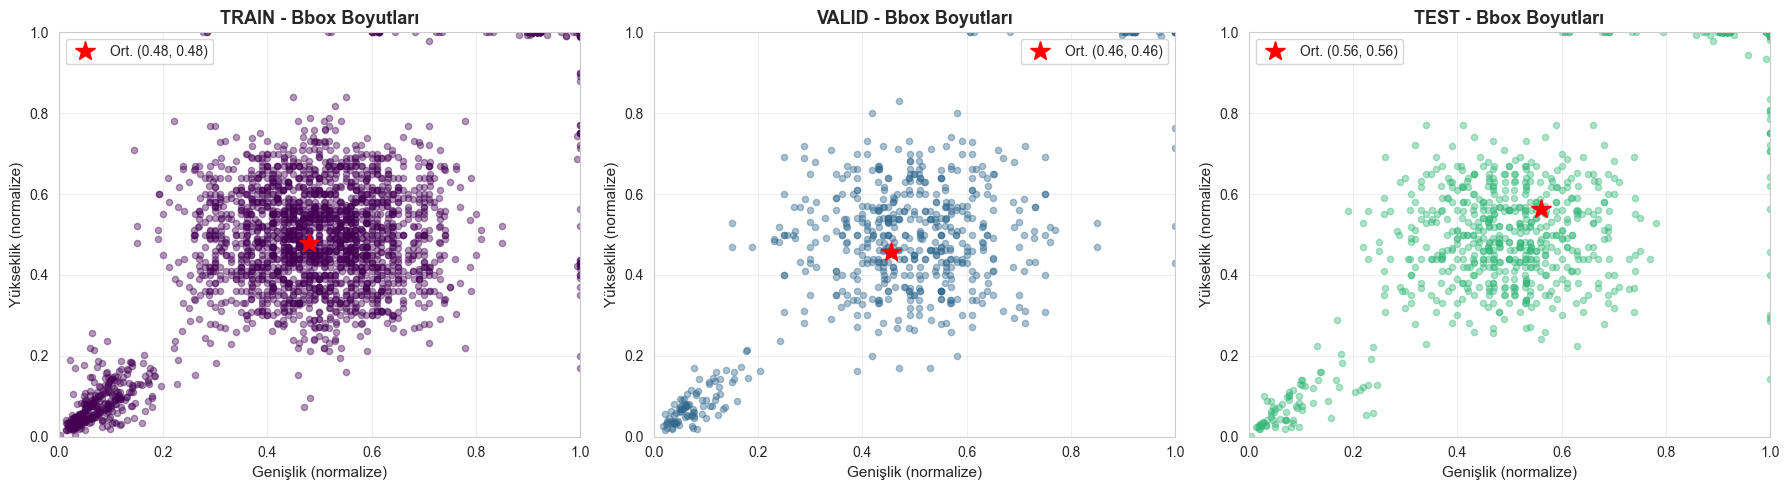

✅ Grafik kaydedildi: bbox_size_distribution.png


In [11]:
# Bbox dağılımını görselleştir
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, split in enumerate(splits):
    if bbox_stats[split]['widths']:
        widths = bbox_stats[split]['widths']
        heights = bbox_stats[split]['heights']
        
        ax = axes[idx]
        ax.scatter(widths, heights, alpha=0.4, s=20, c=plt.cm.viridis(idx/3))
        ax.set_xlabel('Genişlik (normalize)', fontsize=11)
        ax.set_ylabel('Yükseklik (normalize)', fontsize=11)
        ax.set_title(f'{split.upper()} - Bbox Boyutları', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        
        # Ortalama noktası
        mean_w, mean_h = np.mean(widths), np.mean(heights)
        ax.plot(mean_w, mean_h, 'r*', markersize=15, label=f'Ort. ({mean_w:.2f}, {mean_h:.2f})')
        ax.legend()

plt.tight_layout()
plt.savefig('bbox_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafik kaydedildi: bbox_size_distribution.png")

## 9. Özet Rapor ve Öneriler

In [12]:
print("=" * 80)
print("📊 VERİ SETİ ANALİZİ ÖZET RAPORU")
print("=" * 80)

# 1. Genel Bilgiler
print("\n1️⃣  GENEL BİLGİLER:")
print(f"   • Toplam Sınıf: {len(class_names)}")
print(f"   • Toplam Görsel: {total_images}")
print(f"   • Train: {stats['train']['images']} (%{stats['train']['images']/total_images*100:.1f})")
print(f"   • Valid: {stats['valid']['images']} (%{stats['valid']['images']/total_images*100:.1f})")
print(f"   • Test: {stats['test']['images']} (%{stats['test']['images']/total_images*100:.1f})")

# 2. Sınıf Dağılımı
print("\n2️⃣  SINIF DAĞILIMI:")
train_dist = class_distribution['train']
if train_dist:
    total_train_annotations = sum(train_dist.values())
    unique_train_classes = len(train_dist)
    print(f"   • Toplam Annotation (Train): {total_train_annotations}")
    print(f"   • Kullanılan Sınıf Sayısı: {unique_train_classes} / {len(class_names)}")
    print(f"   • Annotation/Görsel: {total_train_annotations/stats['train']['images']:.2f}")
    
    most_common = train_dist.most_common(1)[0]
    least_common = sorted(train_dist.items(), key=lambda x: x[1])[0]
    print(f"   • En Yaygın Sınıf: [{most_common[0]}] - {most_common[1]} örnek")
    print(f"   • En Nadir Sınıf: [{least_common[0]}] - {least_common[1]} örnek")

# 3. Görsel Boyutları
print("\n3️⃣  GÖRSEL BOYUTLARI:")
for split in splits:
    if split in image_sizes and image_sizes[split]:
        sizes = image_sizes[split]
        widths = [s[0] for s in sizes]
        heights = [s[1] for s in sizes]
        print(f"   • {split.upper()}: {np.mean(widths):.0f}x{np.mean(heights):.0f} (ortalama)")

# 4. Tespit Edilen Sorunlar
print("\n4️⃣  TESPİT EDİLEN SORUNLAR:")
issues = []

if stats['test']['images'] < 50:
    issues.append(f"❌ Test seti çok küçük ({stats['test']['images']} görsel)")

if train_dist:
    max_count = train_dist.most_common(1)[0][1]
    min_count = sorted(train_dist.items(), key=lambda x: x[1])[0][1]
    imbalance = max_count / min_count if min_count > 0 else float('inf')
    if imbalance > 50:
        issues.append(f"❌ Yüksek veri dengesizliği ({imbalance:.0f}x)")

unused_classes = len(class_names) - len(train_dist)
if unused_classes > 0:
    issues.append(f"⚠️  {unused_classes} sınıf hiç kullanılmamış")

if issues:
    for issue in issues:
        print(f"   {issue}")
else:
    print("   ✅ Önemli sorun tespit edilmedi!")

# 5. Öneriler
print("\n5️⃣  ÖNERİLER:")
print("   📌 Test setini genişletin (en az 50-100 görsel)")
print("   📌 Veri dengesizliğini gidermek için augmentation kullanın")
print("   📌 Az temsil edilen sınıflar için daha fazla veri toplayın")
print("   📌 Model eğitiminde class_weights kullanmayı düşünün")
print("   📌 Eğitim sonrası per-class performance'ı analiz edin")

print("\n" + "=" * 80)
print("✅ Analiz tamamlandı! Grafikler kaydedildi.")
print("=" * 80)

📊 VERİ SETİ ANALİZİ ÖZET RAPORU

1️⃣  GENEL BİLGİLER:
   • Toplam Sınıf: 264
   • Toplam Görsel: 1358
   • Train: 818 (%60.2)
   • Valid: 185 (%13.6)
   • Test: 355 (%26.1)

2️⃣  SINIF DAĞILIMI:
   • Toplam Annotation (Train): 2642
   • Kullanılan Sınıf Sayısı: 262 / 264
   • Annotation/Görsel: 3.23
   • En Yaygın Sınıf: [57] - 147 örnek
   • En Nadir Sınıf: [169] - 1 örnek

3️⃣  GÖRSEL BOYUTLARI:
   • TRAIN: 640x640 (ortalama)
   • VALID: 640x640 (ortalama)
   • TEST: 640x640 (ortalama)

4️⃣  TESPİT EDİLEN SORUNLAR:
   ❌ Yüksek veri dengesizliği (147x)
   ⚠️  2 sınıf hiç kullanılmamış

5️⃣  ÖNERİLER:
   📌 Test setini genişletin (en az 50-100 görsel)
   📌 Veri dengesizliğini gidermek için augmentation kullanın
   📌 Az temsil edilen sınıflar için daha fazla veri toplayın
   📌 Model eğitiminde class_weights kullanmayı düşünün
   📌 Eğitim sonrası per-class performance'ı analiz edin

✅ Analiz tamamlandı! Grafikler kaydedildi.


---
## 🎯 VERİ DENGESİZLİĞİ ÇÖZÜMÜ UYGULANDI!

### ✅ yolov8_train_local.ipynb'de Yapılan İyileştirmeler:

#### 1. **Class Loss Gain Artırıldı (0.5 → 1.0)**
   - Nadir sınıfların classification loss'u 2x daha fazla ağırlıklandırıldı
   - Bu, modelin nadir sınıfları daha iyi öğrenmesini sağlar

#### 2. **Güçlendirilmiş Data Augmentation:**
   - **MixUp (0% → 15%):** İki görseli karıştırarak yeni sentetik örnekler oluşturur
   - **Copy-Paste (0% → 30%):** Nesneleri farklı görsellere kopyalayarak çeşitlilik arttırır
   - **Geometrik Augmentations:**
     - Rotation: ±10° (yeni!)
     - Shear: 5° (yeni!)  
     - Perspective: 0.0005 (yeni!)
     - Translation: %15 (artırıldı)
     - Scale: 0.7 (artırıldı)
   - **Renk Augmentations:** HSV değerleri artırıldı

#### 3. **Close Mosaic: 10 → 15 epoch**
   - Mosaic augmentation daha uzun süre aktif kalacak

### 📈 Beklenen İyileştirmeler:
- **Nadir Sınıflar:** 1-10 örnekli sınıfların performansı %20-40 artabilir
- **Genel mAP:** %5-10 iyileşme bekleniyor
- **Confusion Matrix:** Daha dengeli sonuçlar
- **Generalization:** Gerçek dünyada daha iyi performans

### 🚀 Sonraki Adımlar:
1. `yolov8_train_local.ipynb` dosyasını çalıştırın
2. Eğitim bitince confusion matrix'i kontrol edin
3. Nadir sınıfların precision/recall değerlerini inceleyin
4. Gerekirse augmentation parametrelerini ince ayar yapın

---